<a href="https://colab.research.google.com/github/mundundan-star/online-retail-customer-analytics/blob/main/4.0%20Retention_Analysis%20and%20Churn_Labelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect, text
from google.colab import userdata

engine = create_engine(userdata.get("NEON_DATABASE_URL"))

query = """
WITH data AS(
SELECT "CustomerID",
    EXTRACT(MONTH FROM "InvoiceDate") AS "TxnMonth",
    EXTRACT(YEAR FROM "InvoiceDate") AS "TxnYear",
    "CohortMonth",
    "CohortMonth1",
    "CohortYear",
    "Revenue"
FROM v_clean_sales_analytics
LEFT JOIN (SELECT "CustomerID",
          TO_CHAR(MIN("InvoiceDate"), 'YYYY-MM') AS "CohortMonth",
          EXTRACT(MONTH FROM MIN("InvoiceDate")) AS "CohortMonth1",
          EXTRACT(YEAR FROM MIN("InvoiceDate")) AS "CohortYear"
          FROM  v_clean_sales_analytics
          GROUP BY "CustomerID")
USING("CustomerID")
WHERE "InvoiceDate" <= '2011-08-31'),

month_number AS(
SELECT "CustomerID",
    "CohortMonth",
    "CohortMonth1",
    (("TxnYear" - "CohortYear") * 12) + ("TxnMonth" - "CohortMonth1") AS "MonthNumber",
    "Revenue"
FROM data)

SELECT "CohortMonth",
        "MonthNumber",
        COUNT(DISTINCT "CustomerID") AS "NoCustomers"
FROM month_number
GROUP BY "CohortMonth", "MonthNumber"
"""

df = pd.read_sql(text(query), con = engine)

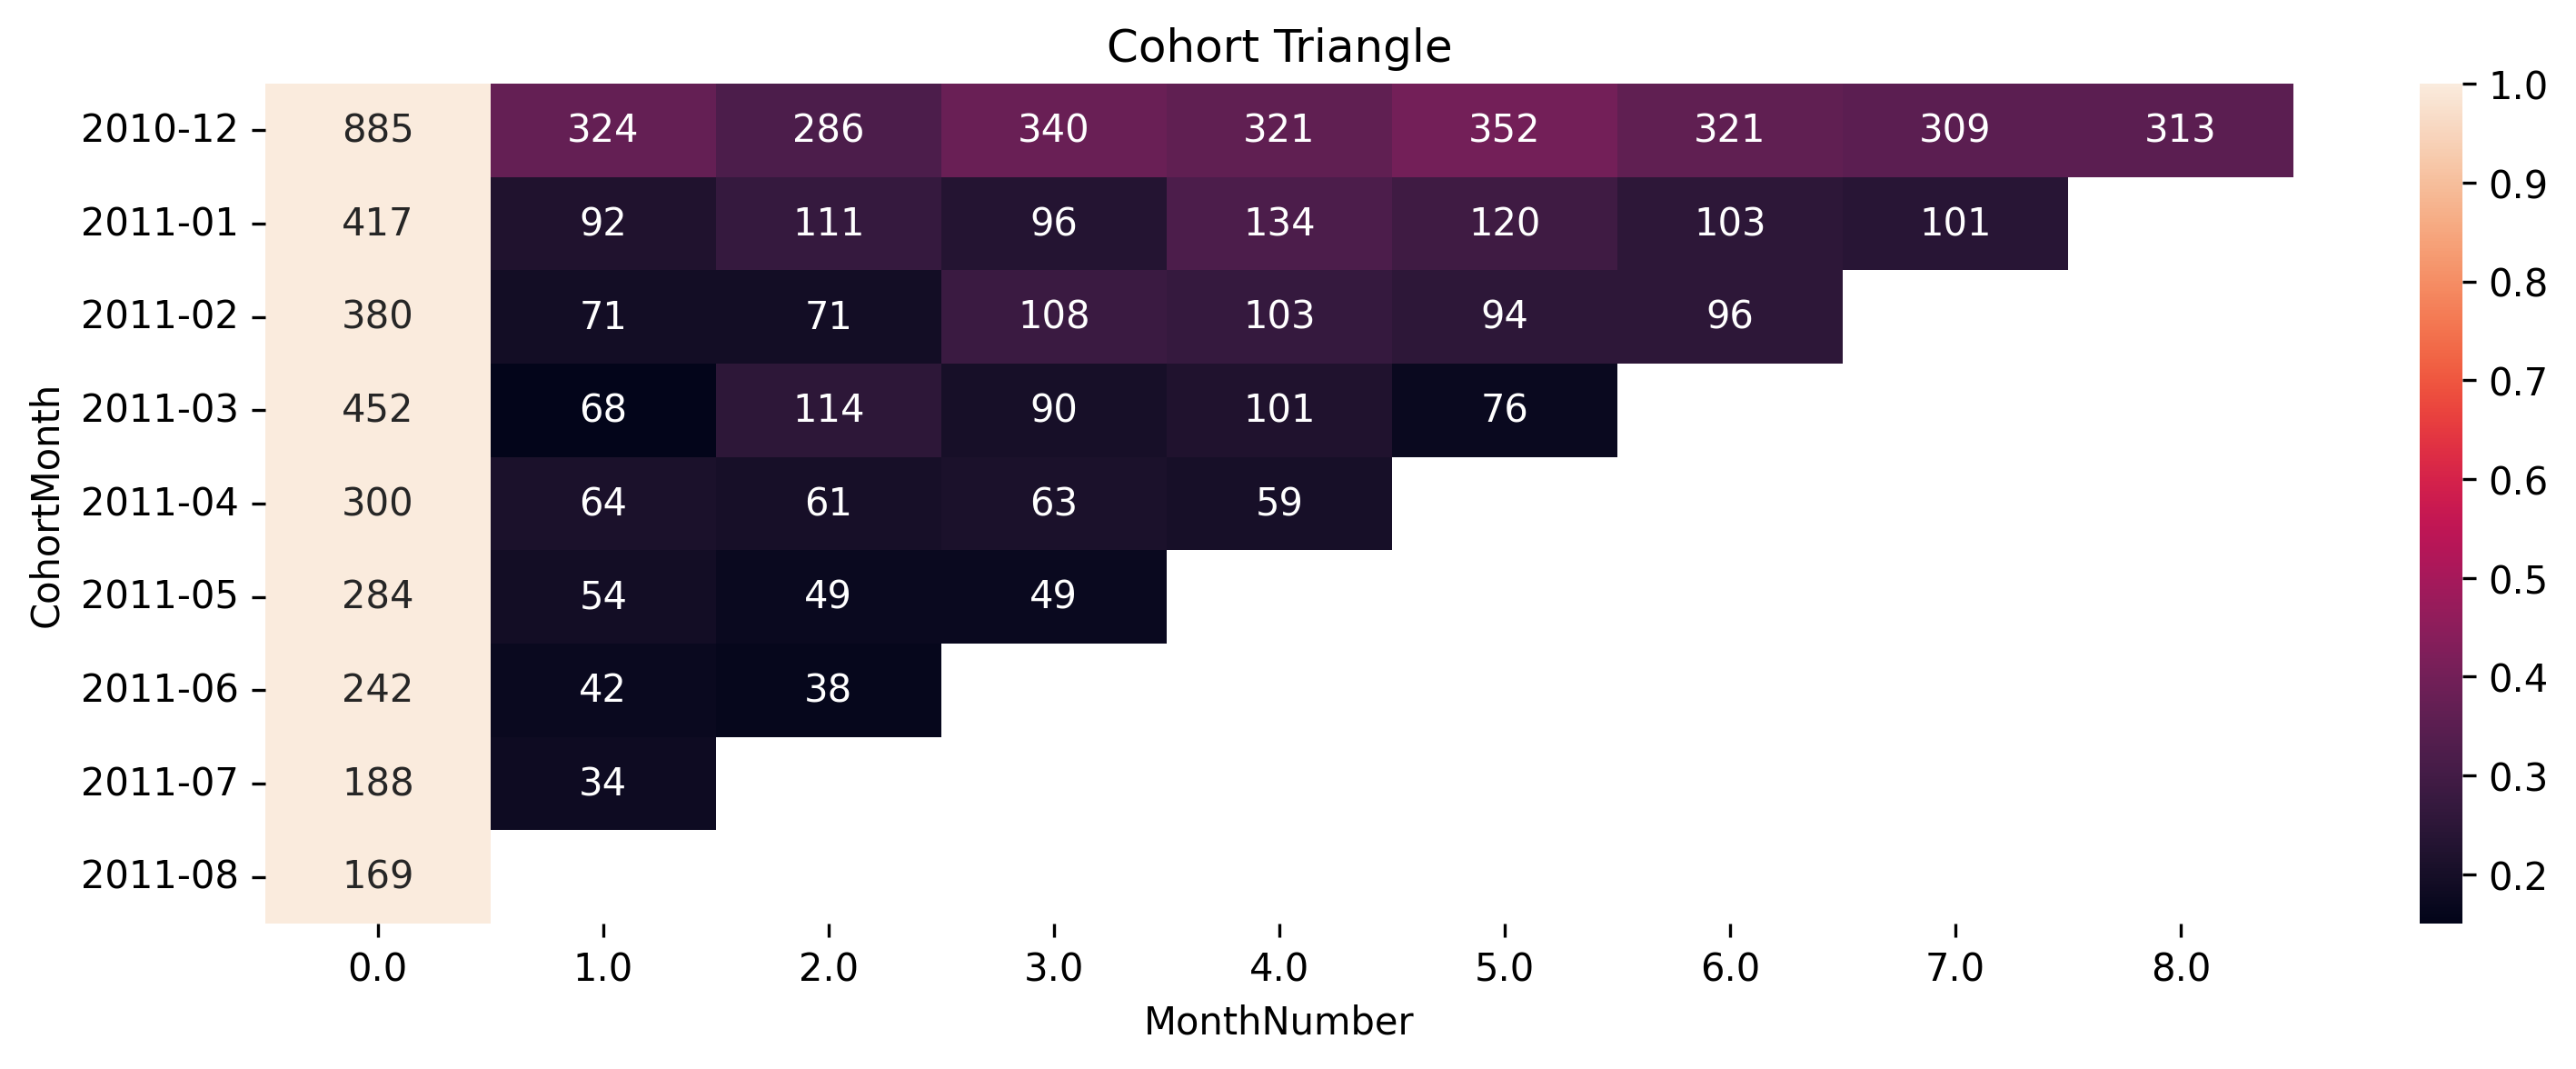

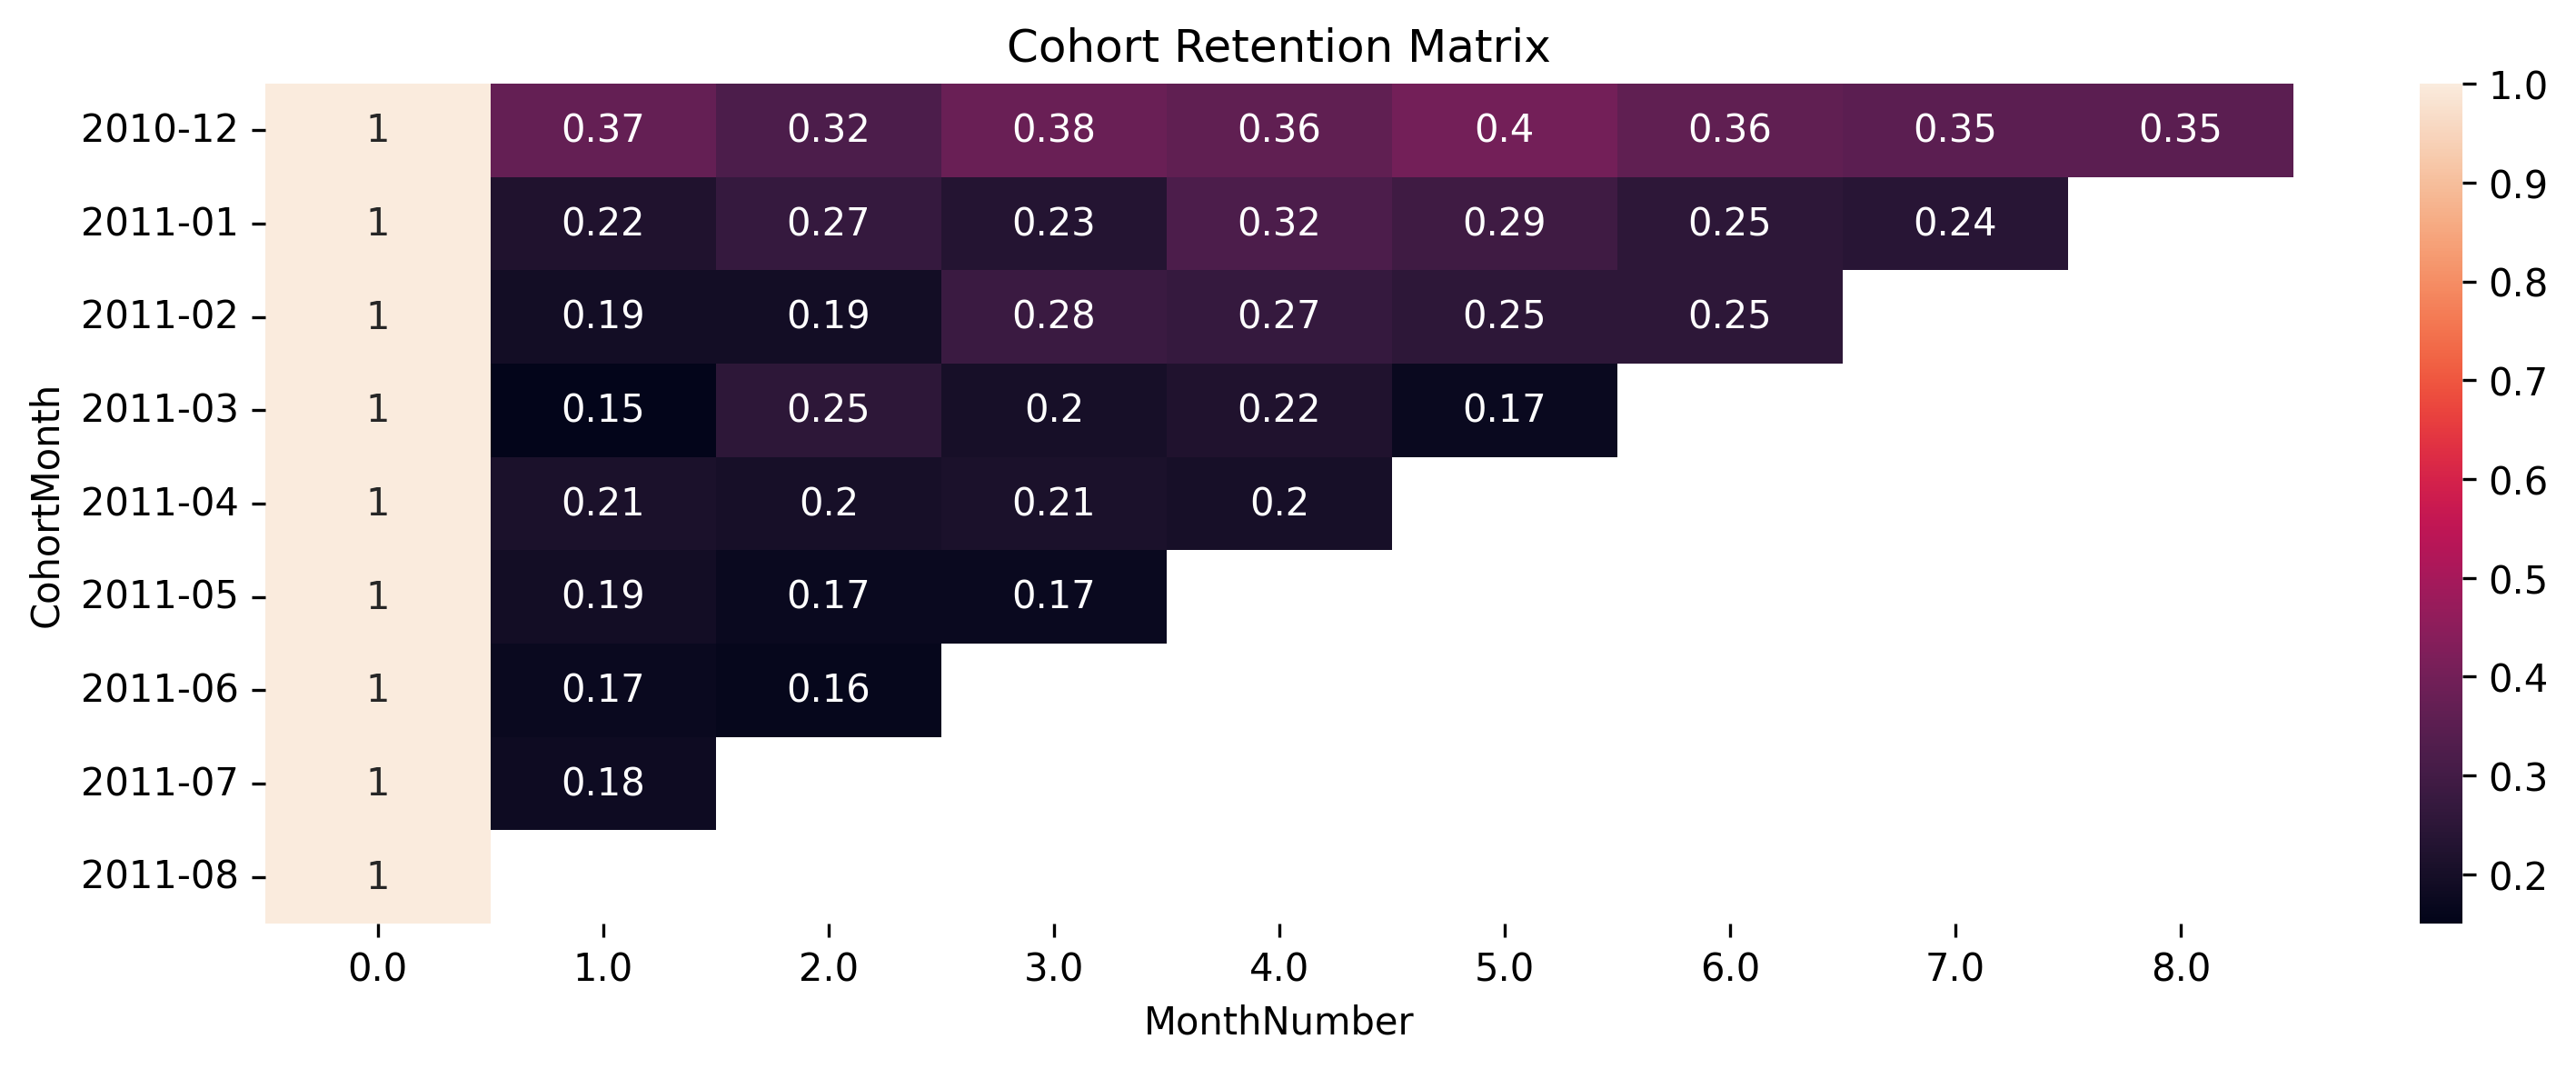

In [13]:
count_pivot = df.pivot_table(index = "CohortMonth", columns = "MonthNumber", values = "NoCustomers")

cohort_size = count_pivot.iloc[:,0]
count_pivot_norm = count_pivot.divide(cohort_size, axis = 0).round(2)

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = count_pivot_norm, annot = count_pivot, fmt = 'g')
plt.title("Cohort Triangle")
plt.show()

plt.figure(figsize = (12,4), dpi = 300)
sns.heatmap(data = count_pivot_norm, annot = count_pivot_norm, fmt = 'g')
plt.title("Cohort Retention Matrix")
plt.show()

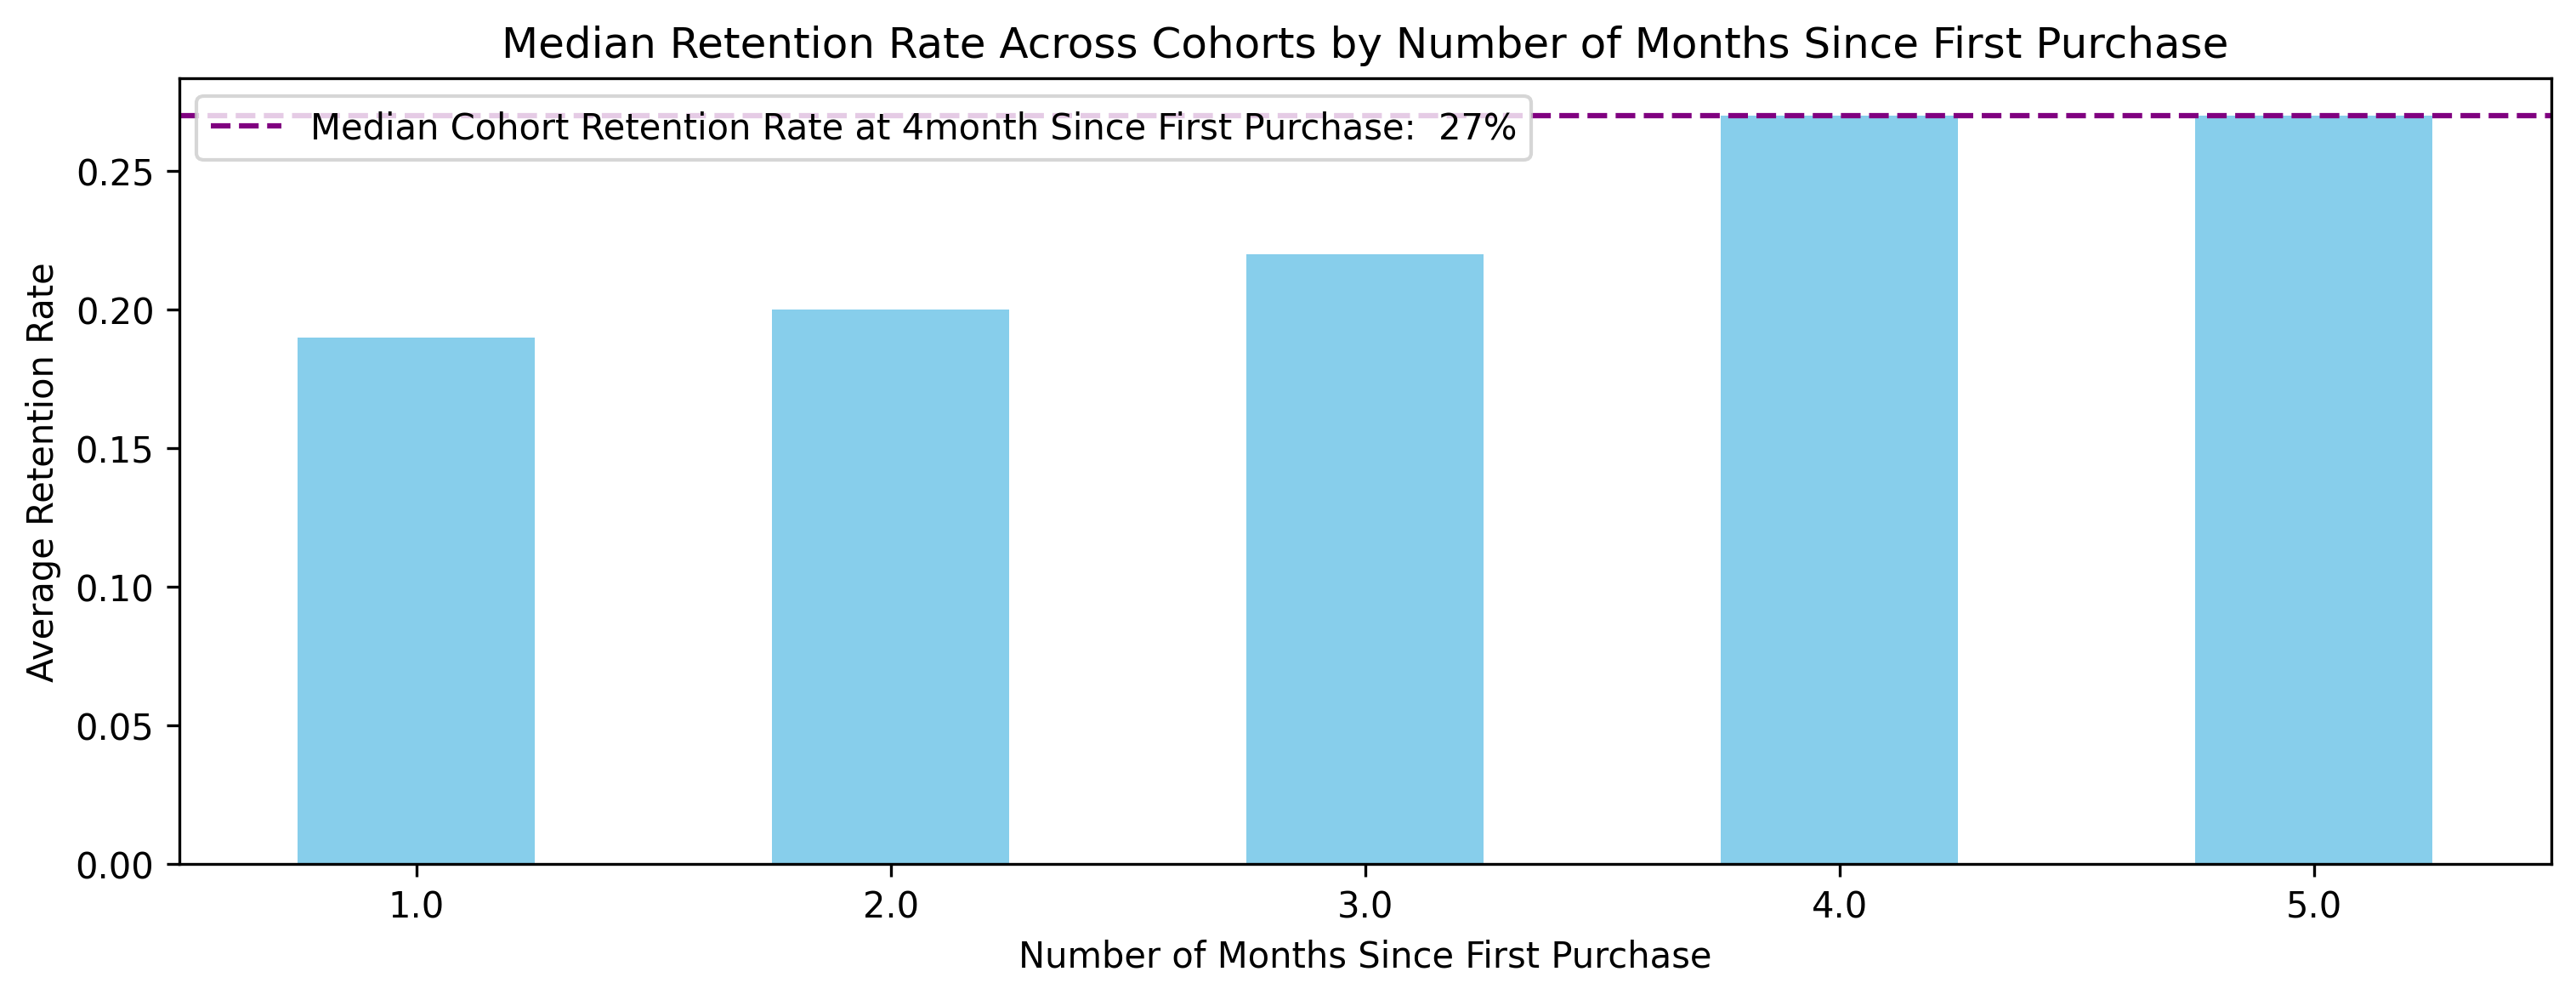

In [14]:

avg_retention = count_pivot_norm.median(axis = 0)

avg_retention = count_pivot_norm.median(axis = 0)
churn= avg_retention[avg_retention.index.isin([1,2,3,4,5])]

plt.figure(figsize = (12,4), dpi = 300)
churn.plot(kind = 'bar', color = 'skyblue')
plt.axhline(y = churn.iloc[3], color = 'purple', linestyle = '--', label = f'Median Cohort Retention Rate at 4month Since First Purchase: {(churn.iloc[4]*100): .0f}%')
plt.ylabel("Average Retention Rate")
plt.xlabel("Number of Months Since First Purchase")
plt.title("Median Retention Rate Across Cohorts by Number of Months Since First Purchase")
plt.xticks(rotation = 0)
plt.legend()
plt.show()


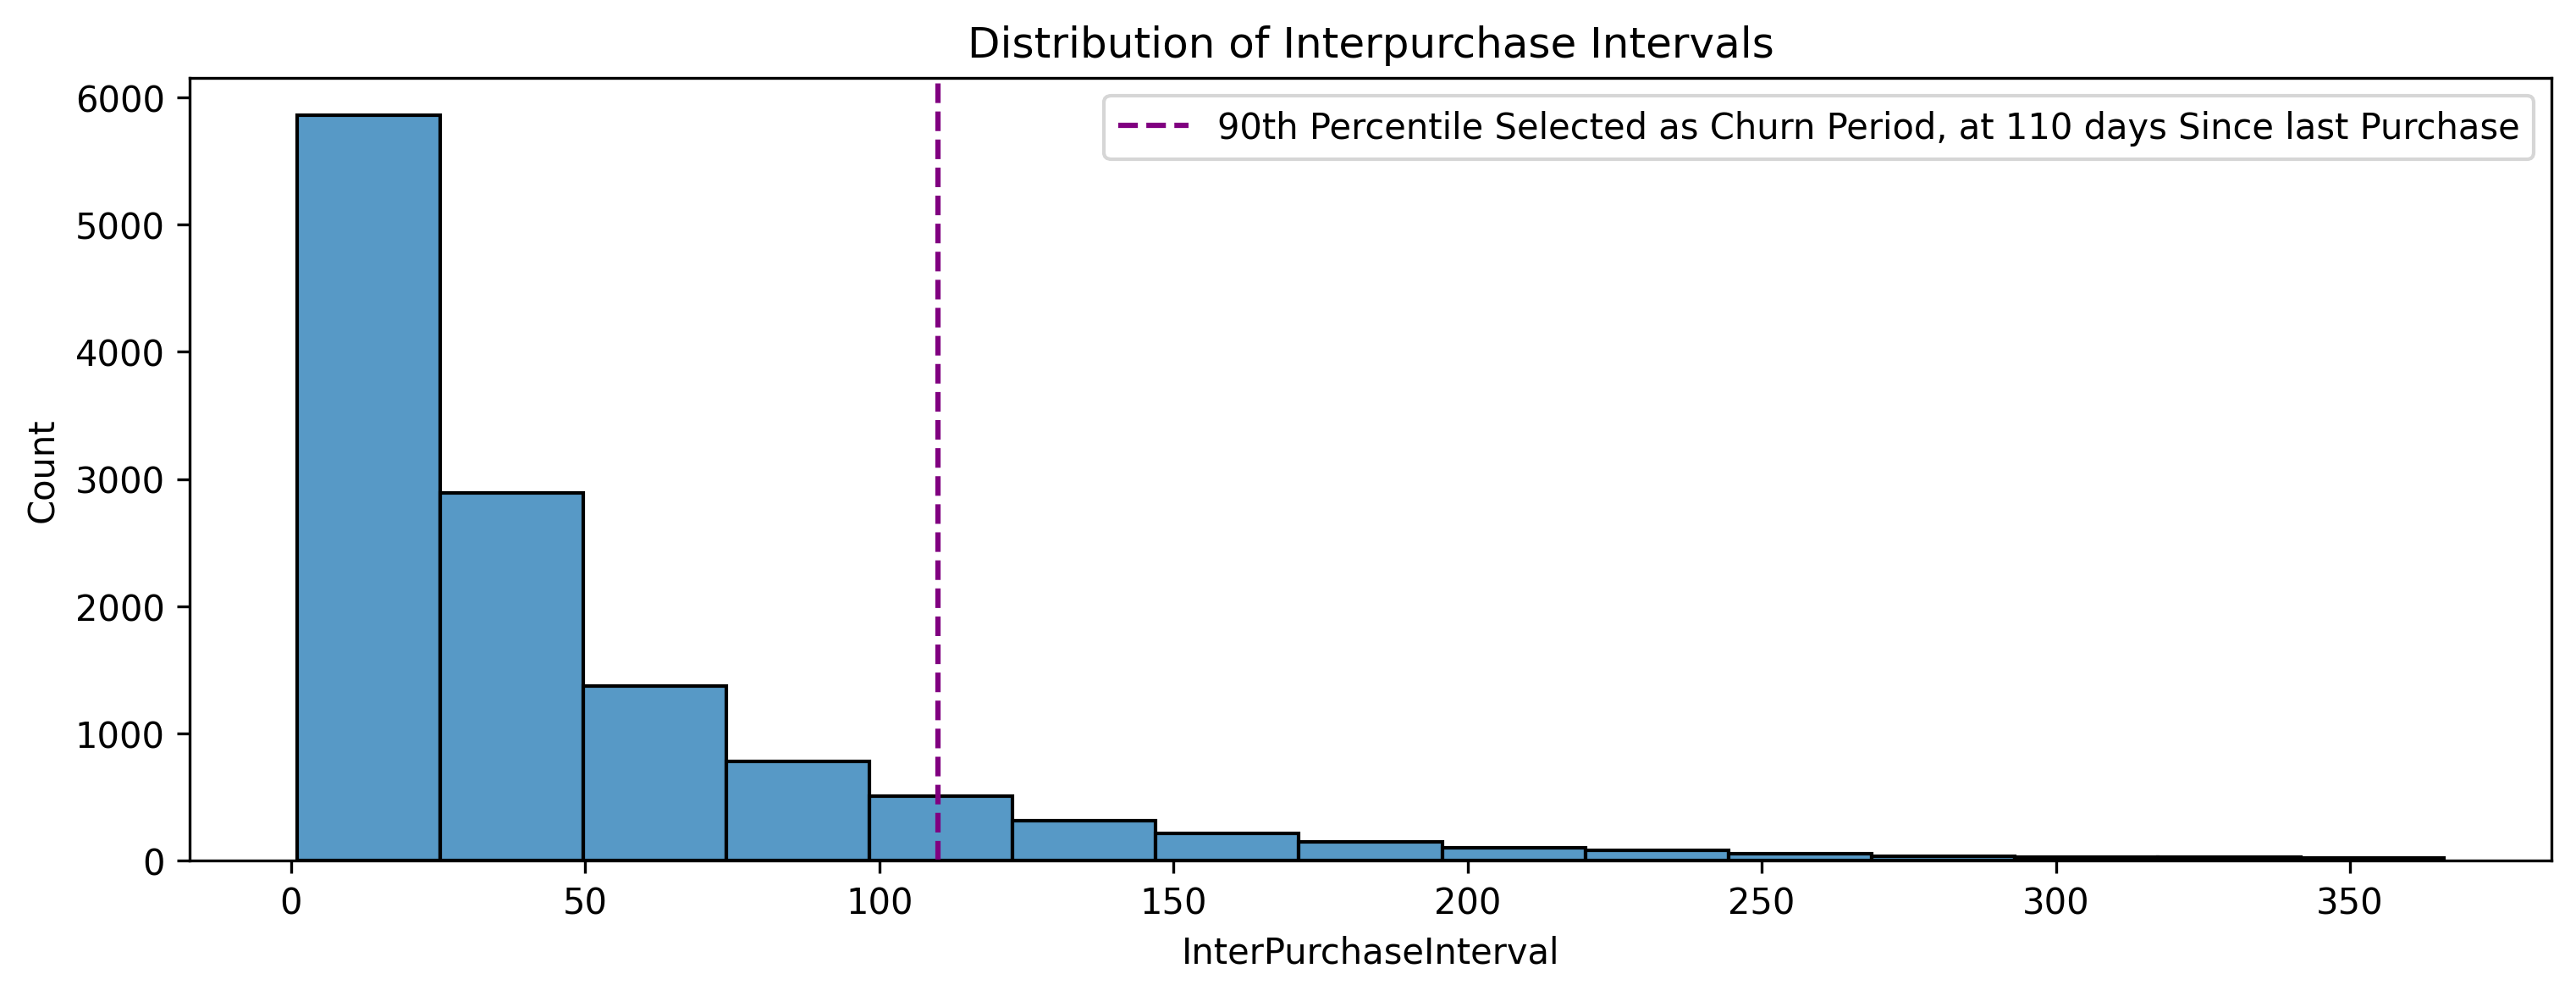

Inter Purchase Interval Quantiles:


,0.10,0.25,0.50,0.75,0.90
0,5.0,12.0,28.0,58.0,110.0


In [15]:
query = """
SELECT "CustomerID",
    "InvoiceDate"
FROM v_clean_sales_analytics
"""

ipi_df = pd.read_sql(text(query), con = engine)

ipi_df.sort_values(["CustomerID", "InvoiceDate"], inplace = True)
ipi_df['InvoiceDate'] = pd.to_datetime(ipi_df['InvoiceDate'])

ipi_df['InterPurchaseInterval'] = np.where(ipi_df['CustomerID'] == ipi_df['CustomerID'].shift(1),
                                           (ipi_df['InvoiceDate'] - ipi_df['InvoiceDate'].shift(1)).dt.days, 0)


plt.figure(figsize = (12,4), dpi = 300)
sns.histplot(data = ipi_df.query('InterPurchaseInterval!= 0'), x = 'InterPurchaseInterval', bins = 15)
plt.axvline(x = 110, label = "90th Percentile Selected as Churn Period, at 110 days Since last Purchase", linestyle = '--', color = 'purple')
plt.title("Distribution of Interpurchase Intervals")
plt.legend()
plt.show()

print('Inter Purchase Interval Quantiles:')
pd.DataFrame(np.quantile(ipi_df.query('InterPurchaseInterval > 0')['InterPurchaseInterval'], [0.1, 0.25, 0.5, 0.75, 0.9]), index = [0.1, 0.25, 0.5, 0.75, 0.9]).transpose()

In [30]:
engine= create_engine(userdata.get('NEON_DATABASE_URL'))

query = """
CREATE OR REPLACE VIEW v_churn_analysis_candidates AS
WITH data AS(
SELECT "CustomerID",
    MIN("InvoiceDate") AS "MinDate",
    MAX("InvoiceDate") AS "MaxDate"
FROM v_clean_sales_analytics
WHERE "InvoiceDate" > '2011-08-31'
GROUP BY "CustomerID")

SELECT *,
  "LastPurchase" + 110 AS "LastDate+ChurnPeriod",
  CASE WHEN "MinDate" IS NULL THEN 'No_Purchase'
      ELSE 'Purchased'
  END "ActionAfterAugust",
  ("MinDate" - "LastPurchase") AS "AfterAugustInterval",
  CASE WHEN ("MinDate" - "LastPurchase") > 110 OR ("MinDate" - "LastPurchase") IS NULL THEN 1
    ELSE 0
  END AS "Churned"
FROM data
FULL OUTER JOIN (SELECT "CustomerID",
          "LastPurchase"
          FROM v_customer_metrics)
          --WHERE "Recency" < 110) --outer join: to pull data from both tables without excluding any
          -- Excluded clients with recency greater than 110 as they have already churned as at August 31st
USING("CustomerID")
WHERE "LastPurchase" IS NOT NULL -- Ensures new customers without histor in v_customer meterics are excluded
--AND ("MinDate" + 110) < (SELECT MAX("MaxDate")
                            --FROM data) -- Ensures Customers Whose Expected Churn  date exceeds the dataset end, as we can't know what they'll do
ORDER BY "AfterAugustInterval"
"""

with engine.begin() as conn:
    conn.execute(text(query))

query = """
SELECT *
FROM v_churn_analysis_candidates
"""
df = pd.read_sql(text(query), con = engine)

print("Sql Query output:")
df.head()

Sql Query output:


,CustomerID,MinDate,MaxDate,LastPurchase,LastDate+ChurnPeriod,ActionAfterAugust,AfterAugustInterval,Churned
0,13089.0,2011-09-01,2011-12-07,2011-08-31,2011-12-19,Purchased,1.0,0
1,17949.0,2011-09-01,2011-12-08,2011-08-31,2011-12-19,Purchased,1.0,0
2,15856.0,2011-09-02,2011-12-05,2011-08-31,2011-12-19,Purchased,2.0,0
3,14096.0,2011-09-02,2011-12-05,2011-08-30,2011-12-18,Purchased,3.0,0
4,12748.0,2011-09-02,2011-12-09,2011-08-30,2011-12-18,Purchased,3.0,0


In [31]:
churned = pd.DataFrame(df['Churned'].value_counts())
churned['Description'] = [ "Retained clients after August 31st" ,"No. of clients that churned after August 31st"]
churn_rate = churned['count'].iloc[0]/(churned['count'].iloc[1] + churned['count'].iloc[0])
print(f"Retention rate   {churn_rate *100: .2f}%")
print('\nFrequency of Clients that Will be used to train Machine learning models')
churned

Retention rate    64.52%

Frequency of Clients that Will be used to train Machine learning models


,count,Description
Churned,,
1,2140,Retained clients after August 31st
0,1177,No. of clients that churned after August 31st
